In [ ]:
# Install required packages in Google Colab
!pip install numpy==1.19.2
!pip install tensorflow==2.4
!pip install torch==1.7.0
!pip install torchsummary==1.5.1
!pip install torchvision==0.8.1
!pip install matplotlib
!pip install ipython

  Using cached numpy-1.19.2.zip (7.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
ERROR: Exception:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/reso

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from IPython import display
import matplotlib.pyplot as plt
# %matplotlib inline
from tensorflow import keras

In [ ]:
tf.__version__

'2.19.0'

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_train = (x_train - 127.5) / 127.5 # Normalize the images to [-1, 1]
# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).\
shuffle(60000).batch(128)

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
BUFFER_SIZE = 60000
BATCH_SIZE = 128

In [ ]:
latent_dim = 100
image_dim = 784

In [ ]:
num_examples_to_generate = 25
# We will reuse this seed overtime to visualize progress
seed = tf.random.normal([num_examples_to_generate, latent_dim])

In [ ]:
def generator(image_dim):

    inputs = keras.Input(shape=(100,), name='input_layer')
    x = layers.Dense(128, kernel_initializer=tf.keras.initializers.he_uniform, name='dense_1')(inputs)
    #print(x.dtype)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)
    x = layers.Dense(256, kernel_initializer=tf.keras.initializers.he_uniform, name='dense_2')(x)
    x = layers.BatchNormalization(momentum=0.1,  epsilon=0.8, name='bn_1')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)
    x = layers.Dense(512, kernel_initializer=tf.keras.initializers.he_uniform, name='dense_3')(x)
    x = layers.BatchNormalization(momentum=0.1,  epsilon=0.8, name='bn_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_3')(x)
    x = layers.Dense(1024, kernel_initializer=tf.keras.initializers.he_uniform,  name='dense_4')(x)
    x = layers.BatchNormalization(momentum=0.1,  epsilon=0.8, name='bn_3')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_4')(x)
    x = layers.Dense(image_dim, kernel_initializer=tf.keras.initializers.he_uniform, activation='tanh',  name='dense_5')(x)
    outputs = layers.Reshape((28, 28, 1), name='Reshape_Layer')(x) # Changed tf.reshape to layers.Reshape
    model = tf.keras.Model(inputs, outputs, name="Generator")
    return model

In [ ]:
generator = generator(image_dim)

In [ ]:
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyReLU)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_2 (LeakyReLU)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_3 (LeakyReLU)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_4 (LeakyReLU)        │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape_Layer (Reshape)         │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,513,616 (5.77 MB)

 Trainable params: 1,510,032 (5.76 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
def discriminator():
    inputs = keras.Input(shape=(28,28,1), name='input_layer')
    x = layers.Reshape((-1, 784), name='reshape_layer')(inputs)
    x = layers.Dense(512, kernel_initializer=tf.keras.initializers.he_uniform, name='dense_1')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)
    x = layers.Dense(256, kernel_initializer=tf.keras.initializers.he_uniform, name='dense_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)
    outputs = layers.Dense(1, kernel_initializer=tf.keras.initializers.he_uniform, activation='sigmoid', name='dense_3') (x)
    model = tf.keras.Model(inputs, outputs, name="Discriminator")
    return model

In [ ]:
discriminator = discriminator()
#discriminator.save('disc.h5')

In [ ]:
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_layer (Reshape)         │ (None, 1, 784)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1, 512)         │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_1 (LeakyReLU)        │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1, 256)         │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu_2 (LeakyReLU)        │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1, 1)           │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
binary_cross_entropy = tf.keras.losses.BinaryCrossentropy()

In [ ]:
def generator_loss(fake_output):
    gen_loss = binary_cross_entropy(tf.ones_like(fake_output), fake_output)
    print(gen_loss)
    return gen_loss

In [ ]:
def discriminator_loss(real_output, fake_output):
    real_loss = binary_cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = binary_cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    print(total_loss)
    return total_loss

In [ ]:
learning_rate = 0.0002

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0002, beta_1 = 0.5, beta_2 = 0.999 )
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0002, beta_1 = 0.5, beta_2 = 0.999 )

In [ ]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)


    gradients_of_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)


    generator_optimizer.apply_gradients(zip(gradients_of_gen,\
    generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_disc,\
    discriminator.trainable_variables))
    return gen_loss, disc_loss

In [ ]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)


    gradients_of_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)


    generator_optimizer.apply_gradients(zip(gradients_of_gen,\
    generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_disc,\
    discriminator.trainable_variables))
    return gen_loss, disc_loss

In [ ]:
!mkdir tensor

mkdir: cannot create directory ‘tensor’: File exists


In [ ]:
import os
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [ ]:
def train(dataset, epochs):
    G_loss_history, D_loss_history = [], []

    for epoch in range(epochs):
        start = time.time()
        D_loss_list, G_loss_list = [], []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            G_loss_list.append(g_loss.numpy())
            D_loss_list.append(d_loss.numpy())

        G_loss_history.append(np.mean(G_loss_list))
        D_loss_history.append(np.mean(D_loss_list))

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(f'Epoch {epoch + 1} | Time: {time.time()-start:.1f}s')

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

    return G_loss_history, D_loss_history

In [ ]:
def generate_and_save_images(model, epoch, test_input):
  # Notice `training` is set to False.
  # This is so all layers run in inference mode (batchnorm).
    predictions = model(test_input, training=False)
    #print(predictions.shape)
    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(5, 5, i+1)
        pred = (predictions[i, :, :, 0] + 1) * 127.5
        pred = np.array(pred)
        plt.imshow(pred.astype(np.uint8), cmap='gray')
        plt.axis('off')

    plt.savefig('tensor/image_at_epoch_{:d}.png'.format(epoch))
    plt.show()

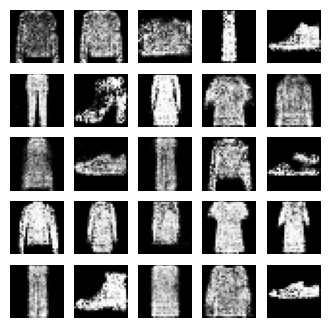

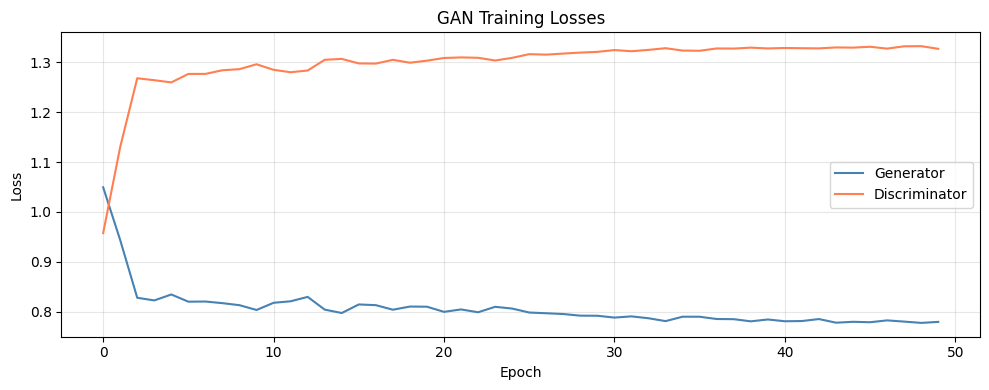

In [ ]:
# Train baseline
G_loss_history, D_loss_history = train(train_dataset, 50)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(G_loss_history, label='Generator', color='steelblue')
plt.plot(D_loss_history, label='Discriminator', color='coral')
plt.title('GAN Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Improvement Pipeline

In [ ]:
def generator_v2(image_dim, latent_dim=100):
    inputs = keras.Input(shape=(latent_dim,), name='input_layer')

    # --- Project and reshape into spatial feature map ---
    x = layers.Dense(7 * 7 * 256, use_bias=False, name='dense_project')(inputs)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5, name='bn_project')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_project')(x)
    x = layers.Reshape((7, 7, 256), name='reshape_to_spatial')(x)

    # --- Upsample 7x7 → 14x14 ---
    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding='same',
                                use_bias=False, kernel_initializer='glorot_uniform',
                                name='convT_1')(x)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5, name='bn_1')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)

    # --- Upsample 14x14 → 28x28 ---
    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding='same',
                                use_bias=False, kernel_initializer='glorot_uniform',
                                name='convT_2')(x)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5, name='bn_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)

    # --- Refine at 28x28 ---
    x = layers.Conv2DTranspose(32, kernel_size=3, strides=1, padding='same',
                                use_bias=False, kernel_initializer='glorot_uniform',
                                name='convT_3')(x)
    x = layers.BatchNormalization(momentum=0.9, epsilon=1e-5, name='bn_3')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_3')(x)

    # --- Output: 28x28x1, tanh activation ---
    outputs = layers.Conv2DTranspose(1, kernel_size=3, strides=1, padding='same',
                                      activation='tanh', kernel_initializer='glorot_uniform',
                                      name='output_layer')(x)

    model = tf.keras.Model(inputs, outputs, name='Generator_v2')
    return model

In [ ]:
def discriminator_v2():
    inputs = keras.Input(shape=(28, 28, 1), name='input_layer')

    # --- 28x28 → 14x14 ---
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding='same',
                      use_bias=False, kernel_initializer='glorot_uniform',
                      name='conv_1')(inputs)
    x = layers.LeakyReLU(0.2, name='leaky_relu_1')(x)
    x = layers.Dropout(0.3, name='dropout_1')(x)

    # --- 14x14 → 7x7 ---
    x = layers.Conv2D(128, kernel_size=4, strides=2, padding='same',
                      use_bias=False, kernel_initializer='glorot_uniform',
                      name='conv_2')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # --- Refine at 7x7 ---
    x = layers.Conv2D(256, kernel_size=3, strides=1, padding='same',
                      use_bias=False, kernel_initializer='glorot_uniform',
                      name='conv_3')(x)
    x = layers.LeakyReLU(0.2, name='leaky_relu_3')(x)
    x = layers.Dropout(0.3, name='dropout_3')(x)

    # --- Classify ---
    x = layers.Flatten(name='flatten')(x)
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = tf.keras.Model(inputs, outputs, name='Discriminator_v2')
    return model

In [ ]:
# Instantiate the improved generator model
generator_v2 = generator_v2(image_dim)
discriminator_v2 = discriminator_v2()

In [ ]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0002, beta_1 = 0.5, beta_2 = 0.999 )
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0002, beta_1 = 0.5, beta_2 = 0.999 )

In [ ]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step_improvement(images):
    noise = tf.random.normal([BATCH_SIZE, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator_v2(noise, training=True)

        real_output = discriminator_v2(images, training=True)
        fake_output = discriminator_v2(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)


    gradients_of_gen = gen_tape.gradient(gen_loss, generator_v2.trainable_variables)
    gradients_of_disc = disc_tape.gradient(disc_loss, discriminator_v2.trainable_variables)


    generator_optimizer.apply_gradients(zip(gradients_of_gen,
    generator_v2.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_disc,
    discriminator_v2.trainable_variables))
    return gen_loss, disc_loss

In [ ]:
import os
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")



checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator_v2,
                                 discriminator=discriminator_v2)

In [ ]:
def train(dataset, epochs):
    G_loss_history, D_loss_history = [], []

    for epoch in range(epochs):
        start = time.time()
        D_loss_list, G_loss_list = [], []

        for image_batch in dataset:
            g_loss, d_loss = train_step_improvement(image_batch)
            G_loss_list.append(g_loss.numpy())
            D_loss_list.append(d_loss.numpy())

        G_loss_history.append(np.mean(G_loss_list))
        D_loss_history.append(np.mean(D_loss_list))

        display.clear_output(wait=True)
        generate_and_save_images(generator_v2, epoch + 1, seed)

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(f'Epoch {epoch + 1} | Time: {time.time()-start:.1f}s')

    display.clear_output(wait=True)
    generate_and_save_images(generator_v2, epochs, seed)

    return G_loss_history, D_loss_history

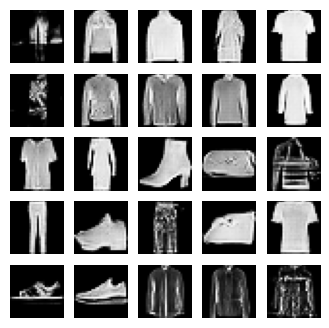

[np.float32(0.9789486), np.float32(0.8839596), np.float32(0.89938116), np.float32(0.8730379), np.float32(0.83519846), np.float32(0.82579017), np.float32(0.81757784), np.float32(0.8118813), np.float32(0.80405366), np.float32(0.7994959), np.float32(0.79340917), np.float32(0.7934468), np.float32(0.79291826), np.float32(0.7951284), np.float32(0.7928834), np.float32(0.7928588), np.float32(0.79743433), np.float32(0.79571944), np.float32(0.7928851), np.float32(0.7912203), np.float32(0.79327667), np.float32(0.7999262), np.float32(0.79276633), np.float32(0.7957353), np.float32(0.7937423), np.float32(0.7984812), np.float32(0.79328716), np.float32(0.79561883), np.float32(0.79726726), np.float32(0.7996923), np.float32(0.7975158), np.float32(0.7979519), np.float32(0.7993327), np.float32(0.8008726), np.float32(0.80018926), np.float32(0.79770476), np.float32(0.79621536), np.float32(0.79867715), np.float32(0.7987288), np.float32(0.79912406), np.float32(0.7967913), np.float32(0.7964272), np.float32(0.8

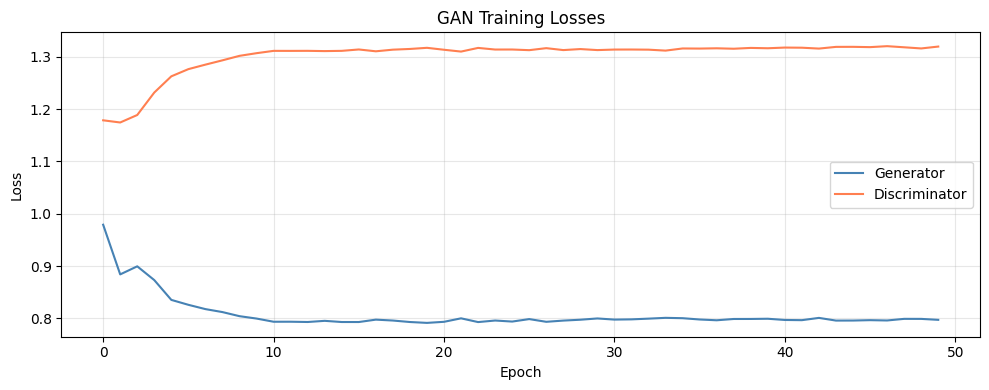

In [ ]:
# Train improved architechture
G_new_loss_history, D_new_loss_history = train(train_dataset, 50)
print(G_new_loss_history)
print(D_new_loss_history)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(G_new_loss_history, label='Generator', color='steelblue')
plt.plot(D_new_loss_history, label='Discriminator', color='coral')
plt.title('GAN Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

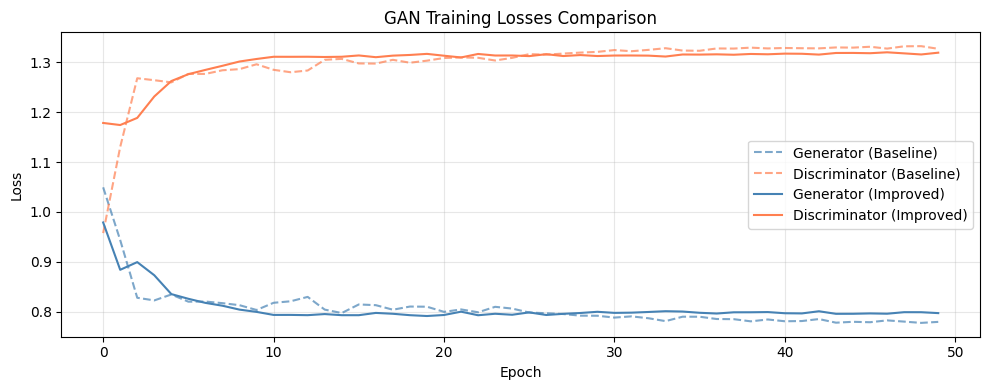

In [ ]:
# Plot (gộp baseline + improved)
plt.figure(figsize=(10, 4))

# --- Baseline ---
plt.plot(G_loss_history, label='Generator (Baseline)', linestyle='--', color='steelblue', alpha=0.7)
plt.plot(D_loss_history, label='Discriminator (Baseline)', linestyle='--', color='coral', alpha=0.7)

# --- Improved ---
plt.plot(G_new_loss_history, label='Generator (Improved)', color='steelblue')
plt.plot(D_new_loss_history, label='Discriminator (Improved)', color='coral')

# --- Decor ---
plt.title('GAN Training Losses Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()